### Wczytanie danych

In [1]:
from pathlib import Path
import pandas as pd

data_dir = Path("dataset")

train_df = pd.read_pickle(data_dir / "dataset_train.pkl")
val_df = pd.read_pickle(data_dir / "dataset_val.pkl")

train_df.info()

<class 'pandas.DataFrame'>
Index: 203 entries, 53 to 228
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   ID_nagrania  203 non-null    str    
 1   sygnał       203 non-null    object 
 2   źródło       203 non-null    str    
 3   label        203 non-null    int64  
 4   qSQI         203 non-null    float64
 5   cSQI         203 non-null    float64
 6   kurtosis     203 non-null    float64
dtypes: float64(3), int64(1), object(1), str(2)
memory usage: 12.7+ KB


# Sieci neuronowe

## 1-D CNN

Epoch  1/25 | Train loss: 0.6917 acc: 0.5911 | Val loss: 0.5888 acc: 0.8039
Epoch  2/25 | Train loss: 0.5617 acc: 0.7241 | Val loss: 0.5296 acc: 0.7059
Epoch  3/25 | Train loss: 0.5329 acc: 0.7438 | Val loss: 0.4886 acc: 0.8039
Epoch  4/25 | Train loss: 0.4983 acc: 0.7143 | Val loss: 0.4585 acc: 0.8039
Epoch  5/25 | Train loss: 0.4542 acc: 0.7488 | Val loss: 0.4694 acc: 0.7255
Epoch  6/25 | Train loss: 0.4058 acc: 0.8177 | Val loss: 0.4213 acc: 0.8627
Epoch  7/25 | Train loss: 0.3548 acc: 0.8571 | Val loss: 0.3898 acc: 0.8431
Epoch  8/25 | Train loss: 0.2964 acc: 0.8768 | Val loss: 0.3520 acc: 0.8235
Epoch  9/25 | Train loss: 0.2438 acc: 0.9113 | Val loss: 0.2932 acc: 0.8235
Epoch 10/25 | Train loss: 0.1883 acc: 0.9163 | Val loss: 0.2531 acc: 0.9020
Epoch 11/25 | Train loss: 0.1327 acc: 0.9606 | Val loss: 0.2187 acc: 0.9216
Epoch 12/25 | Train loss: 0.0959 acc: 0.9852 | Val loss: 0.1803 acc: 0.9216
Epoch 13/25 | Train loss: 0.0703 acc: 0.9852 | Val loss: 0.1656 acc: 0.9216
Epoch 14/25 

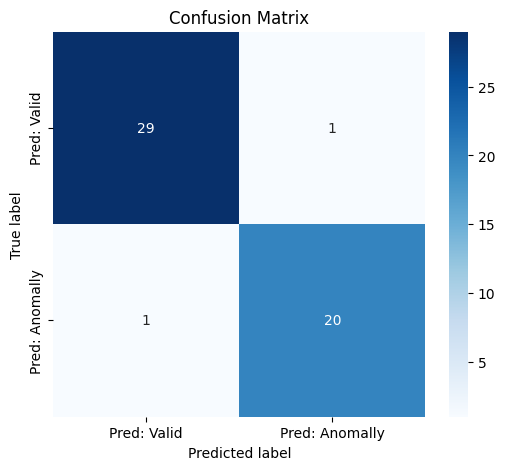

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def prepare_signals(df):
    signals = []
    for idx, s in enumerate(df['sygnał']):
        arr = np.array(s, dtype=np.float32).flatten()
        target_len = 2500
        if arr.size == 0:
            print(f"Warning: Empty signal at index {idx}, skipping.")
            continue
        if len(arr) < target_len:
            arr = np.pad(arr, (0, target_len - len(arr)))
        else:
            arr = arr[:target_len]
        if arr.shape != (target_len,):
            print(f"Warning: Signal at index {idx} has shape {arr.shape}, expected ({target_len},)")
            continue
        signals.append(arr)
    if len(signals) == 0:
        raise ValueError("No valid signals found in the DataFrame.")
    signals = np.stack(signals)
    signals = signals[:, np.newaxis, :]
    return torch.tensor(signals)

def prepare_labels(df):
    return torch.tensor(df['label'].values, dtype=torch.long)

def get_data(train_df, val_df):
    X_train = prepare_signals(train_df)
    X_val = prepare_signals(val_df)
    y_train = prepare_labels(train_df)
    y_val = prepare_labels(val_df)
    return X_train, X_val, y_train, y_val

def get_num_classes(y_train):
    return int(torch.max(y_train).item() + 1) if y_train.min() == 0 else int(torch.max(y_train).item())

class EKG_CNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.conv1 = nn.Conv1d(1, 16, kernel_size=7, padding=3)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool1d(2)
        self.conv2 = nn.Conv1d(16, 32, kernel_size=5, padding=2)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool1d(2)
        self.conv3 = nn.Conv1d(32, 64, kernel_size=3, padding=1)
        self.relu3 = nn.ReLU()
        self.pool3 = nn.MaxPool1d(2)
        self.flatten = nn.Flatten()
        self.fc = nn.Linear(64 * (2500 // 8), num_classes)
    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = self.pool3(self.relu3(self.conv3(x)))
        x = self.flatten(x)
        x = self.fc(x)
        return x

def train_cnn(X_train, y_train, X_val, y_val, num_classes, num_epochs=25, batch_size=32, lr=1e-3):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    train_ds = TensorDataset(X_train, y_train)
    val_ds = TensorDataset(X_val, y_val)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size)
    model = EKG_CNN(num_classes).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    for epoch in range(1, num_epochs+1):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            outputs = model(xb)
            loss = criterion(outputs, yb)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * xb.size(0)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == yb).sum().item()
            total += yb.size(0)
        train_loss = running_loss / total
        train_acc = correct / total
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                outputs = model(xb)
                loss = criterion(outputs, yb)
                val_loss += loss.item() * xb.size(0)
                _, predicted = torch.max(outputs, 1)
                val_correct += (predicted == yb).sum().item()
                val_total += yb.size(0)
        val_loss = val_loss / val_total
        val_acc = val_correct / val_total
        print(f"Epoch {epoch:2d}/{num_epochs} | Train loss: {train_loss:.4f} acc: {train_acc:.4f} | Val loss: {val_loss:.4f} acc: {val_acc:.4f}")
    return model, val_loader, device

def evaluate_cnn(model, val_loader, device, class_names=None):
    model.eval()
    y_true = []
    y_pred = []
    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(device)
            outputs = model(xb)
            _, predicted = torch.max(outputs, 1)
            y_true.extend(yb.cpu().numpy())
            y_pred.extend(predicted.cpu().numpy())
    print("\nClassification report:")
    print(classification_report(y_true, y_pred))
    print("Confusion matrix:")
    cm = confusion_matrix(y_true, y_pred)
    if class_names is None:
        class_names = [f"Class {i}" for i in range(cm.shape[0])]
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted label')
    plt.ylabel('True label')
    plt.title('Confusion Matrix')
    plt.show()

X_train, X_val, y_train, y_val = get_data(train_df, val_df)
num_classes = get_num_classes(y_train)
model, val_loader, device = train_cnn(X_train, y_train, X_val, y_val, num_classes)
evaluate_cnn(model, val_loader, device, class_names=['Pred: Valid', 'Pred: Anomally'] if num_classes == 2 else None)
